# Running StormCast-CONUS Inference

Basic StormCast-CONUS inference workflow for the full Continental United States.

This example demonstrates how to run a single-member forecast using
StormCast-CONUS, a generative convection-allowing model at 3 km resolution over
the full CONUS HRRR domain. For details about the model see

 - https://arxiv.org/abs/2408.10958

In this example you will learn:

- How to instantiate StormCast-CONUS from a model package
- Creating an HRRR initial-condition data source and a GFS forecast conditioning source
- Running a deterministic forecast with [`earth2studio.run.deterministic`][earth2studio.run.deterministic]
- Post-processing and plotting composite reflectivity and 2-m temperature

## Set Up
StormCast-CONUS requires a low-resolution global conditioning source. We use
[`earth2studio.data.GFS_FX`][earth2studio.data.GFS_FX] (the default), which provides GFS forecast
fields interpolated to the HRRR grid. An analysis source such as
[`earth2studio.data.ARCO`][earth2studio.data.ARCO] can also be used.

In [1]:
import os
from datetime import datetime, timedelta

import numpy as np
from loguru import logger
from tqdm import tqdm

logger.remove()
logger.add(lambda msg: tqdm.write(msg, end=""), colorize=True)

os.makedirs("outputs", exist_ok=True)
from dotenv import load_dotenv

load_dotenv()

from earth2studio.data import HRRR
from earth2studio.io import ZarrBackend
from earth2studio.models.px import StormCastCONUS

# Load the model from the default package
package = StormCastCONUS.load_default_package()

# By default, the model uses GFS_FX as the conditioning data source
# Thus we do not need to explicitly specify the conditioning data source
model = StormCastCONUS.load_model(package)

# Create the HRRR initial-condition data source
data = HRRR()

# Create the IO handler, store in memory
io = ZarrBackend()


CuPy distance computation test failed with error: cuVS >= 24.12 or pylibraft < 24.12 should be installed to use this feature


/__w/earth2studio/earth2studio/.venv/lib/python3.13/site-packages/torch/cuda/__init__.py:64: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
WARNING[XFORMERS]: xFormers can't load C++/CUDA extensions. xFormers was built for:
    PyTorch 2.10.0+cu128 with CUDA 1208 (you have 2.13.0+cu130)
    Python  3.10.19 (you have 3.13.13)
  Please reinstall xformers (see https://github.com/facebookresearch/xformers#installing-xformers)
  Memory-efficient attention, SwiGLU, sparse and more won't be available.
  Set XFORMERS_MORE_DETAILS=1 for more details


## Execute the Workflow
With all components initialized, running the workflow is a single line of Python code.
We save only ``t2m`` and ``refc`` to keep memory usage manageable; the full model
state has 99 channels on the 1024 × 1792 CONUS grid.

For the forecast we will predict 4 hours ahead.

In [2]:
import earth2studio.run as run

nsteps = 4
today = datetime.today() - timedelta(days=1)
date = today.isoformat().split("T")[0]

io = run.deterministic(
    [date],
    nsteps,
    model,
    data,
    io,
    output_coords={"variable": np.array(["t2m", "refc"])},
)

print(io.root.tree())


2026-08-14 04:08:41.370 | INFO     | earth2studio.run:deterministic:85 - Running simple workflow!
2026-08-14 04:08:41.370 | INFO     | earth2studio.run:deterministic:92 - Inference device: cuda
2026-08-14 04:08:42.983 | DEBUG    | earth2studio.data.hrrr:fetch_array:485 - Fetching HRRR grib file: noaa-hrrr-bdp-pds/hrrr.20260813/conus/hrrr.t00z.wrfnatf00.grib2 135201969-1045329
2026-08-14 04:08:42.984 | DEBUG    | earth2studio.data.hrrr:fetch_array:485 - Fetching HRRR grib file: noaa-hrrr-bdp-pds/hrrr.20260813/conus/hrrr.t00z.wrfnatf00.grib2 50932972-1115807
2026-08-14 04:08:42.984 | DEBUG    | earth2studio.data.hrrr:fetch_array:485 - Fetching HRRR grib file: noaa-hrrr-bdp-pds/hrrr.20260813/conus/hrrr.t00z.wrfnatf00.grib2 13790487-2218858
2026-08-14 04:08:42.984 | DEBUG    | earth2studio.data.hrrr:fetch_array:485 - Fetching HRRR grib file: noaa-hrrr-bdp-pds/hrrr.20260813/conus/hrrr.t00z.wrfnatf00.grib2 149413496-1018871
2026-08-14 04:08:42.984 | DEBUG    | earth2studio.data.hrrr:fetch_ar

Fetching HRRR data: 100%|██████████| 99/99 [00:06<00:00, 16.35it/s]

Fetching GFS data:   0%|          | 0/26 [00:00<?, ?it/s]
                                                         
Fetching GFS data:   0%|          | 0/26 [00:00<?, ?it/s]
                                                         
Fetching GFS data:   0%|          | 0/26 [00:00<?, ?it/s]
                                                         
Fetching GFS data:   0%|          | 0/26 [00:00<?, ?it/s]
                                                         
Fetching GFS data:   0%|          | 0/26 [00:00<?, ?it/s]
                                                         
Fetching GFS data:   0%|          | 0/26 [00:00<?, ?it/s]
                                                         
Fetching GFS data:   0%|          | 0/26 [00:00<?, ?it/s]
                                                         
Fetching GFS data:   0%|          | 0/26 [00:00<?, ?it/s]
                                                         
Fet

## Post Processing
The last step is to post-process and visualise the results. We use Cartopy with the
HRRR Lambert Conformal projection to plot the CONUS domain. Both composite
reflectivity and 2-m temperature are shown at the final lead time.

Notice that the Zarr IO function has additional APIs to interact with the stored data.

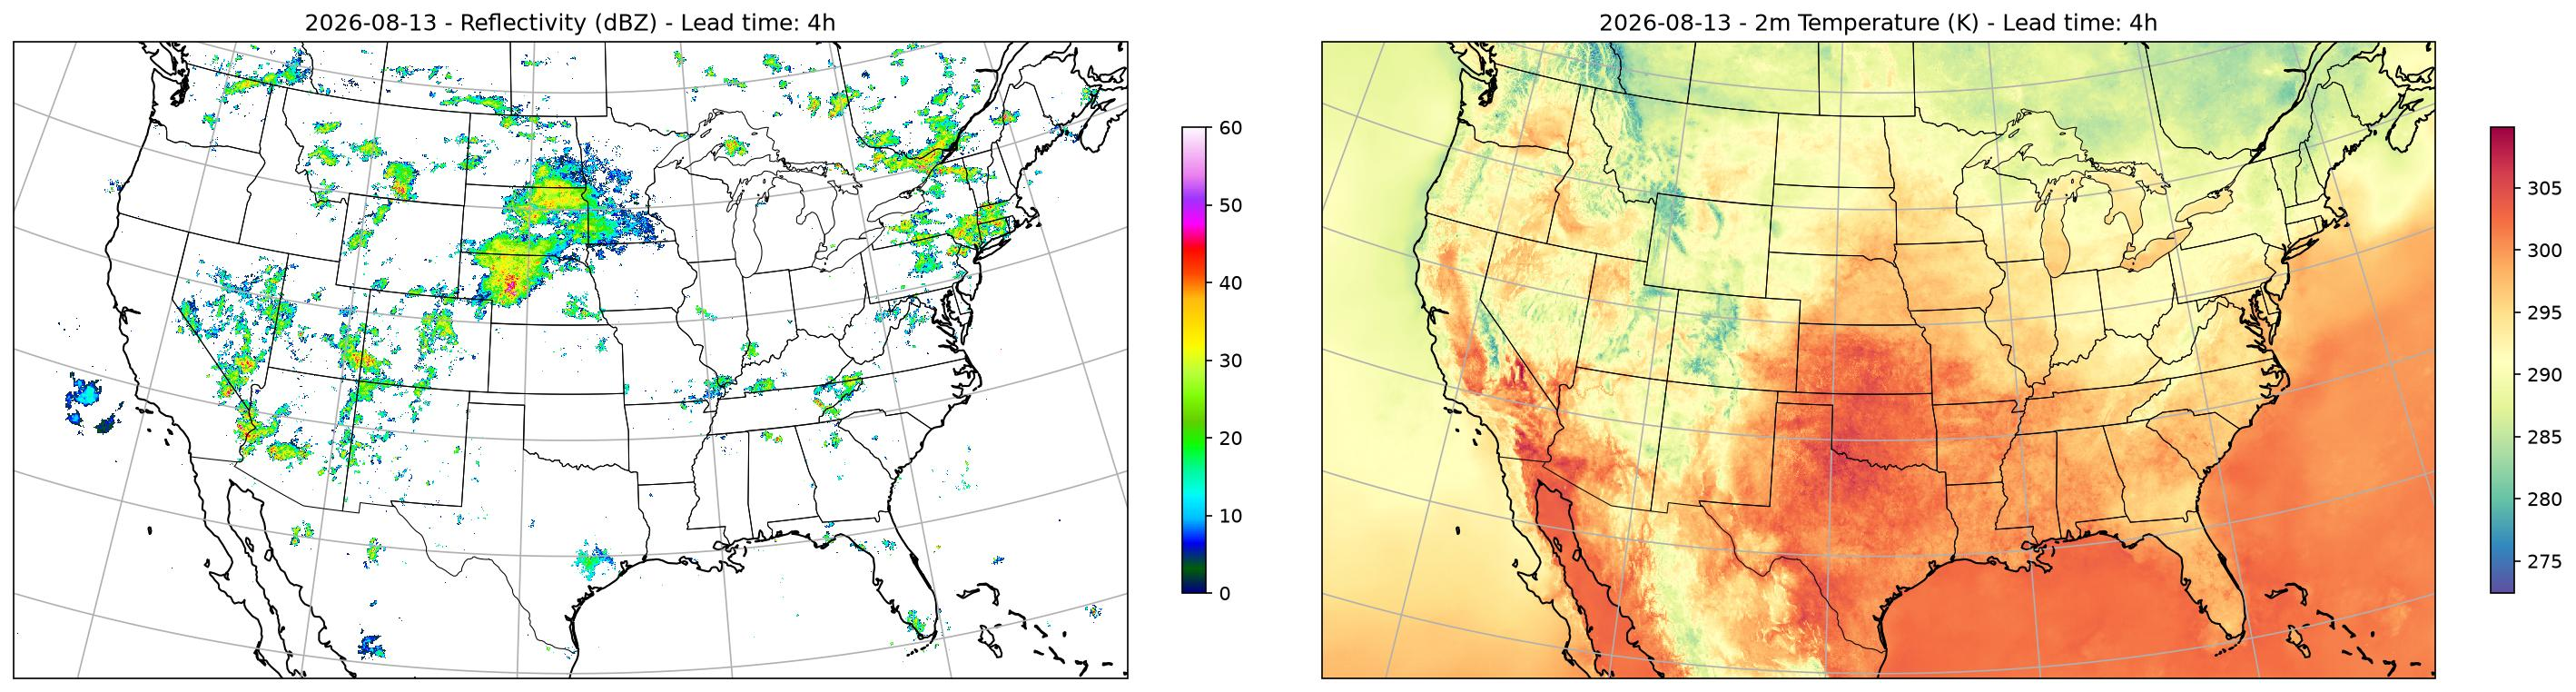

In [3]:
import cartopy
import cartopy.crs as ccrs
import matplotlib.pyplot as plt

forecast = f"{date}"
step = nsteps  # lead time in hours (1 h time step)

# HRRR Lambert Conformal projection
projection = ccrs.LambertConformal(
    central_longitude=262.5,
    central_latitude=38.5,
    standard_parallels=(38.5, 38.5),
    globe=ccrs.Globe(semimajor_axis=6371229, semiminor_axis=6371229),
)


def plot_field(ax, data, title, cmap, vmin=None, vmax=None):
    """Plot a 2-D field on the HRRR Lambert Conformal grid."""
    im = ax.pcolormesh(
        model.lon,
        model.lat,
        data,
        transform=ccrs.PlateCarree(),
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
    )
    plt.colorbar(im, ax=ax, shrink=0.6, pad=0.04)
    ax.set_title(title)
    ax.coastlines()
    ax.gridlines()
    ax.add_feature(
        cartopy.feature.STATES.with_scale("50m"),
        linewidth=0.5,
        edgecolor="black",
        zorder=2,
    )


plt.close("all")
fig, (ax1, ax2) = plt.subplots(
    nrows=1, ncols=2, subplot_kw={"projection": projection}, figsize=(20, 6)
)

# Composite reflectivity — mask sub-zero values which are not physically meaningful
refc = io["refc"][0, step]
plot_field(
    ax1,
    np.where(refc > 0, refc, np.nan),
    f"{forecast} - Reflectivity (dBZ) - Lead time: {step}h",
    cmap="gist_ncar",
    vmin=0,
    vmax=60,
)

# 2-m temperature
plot_field(
    ax2,
    io["t2m"][0, step],
    f"{forecast} - 2m Temperature (K) - Lead time: {step}h",
    cmap="Spectral_r",
)

plt.tight_layout()
plt.savefig(f"outputs/04_{date}_refc_t2m.jpg", dpi=150, bbox_inches="tight")
